In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2. Load dataset
data = pd.read_csv("intern_performance_dataset.csv")

# Quick overview
print(data.head())
print(data.info())
print(data['performance_category'].value_counts())


   intern_id  task_completion_time_hrs  feedback_rating  attendance_percent  \
0  INT_00001                      11.5              5.8                97.4   
1  INT_00002                       9.6              6.6                73.0   
2  INT_00003                      11.9              6.1                85.4   
3  INT_00004                      14.6              6.7                87.7   
4  INT_00005                       9.3              7.2                88.1   

   performance_score performance_category  
0               52.0              Average  
1               41.3             Struggle  
2               48.2              Average  
3               41.0             Struggle  
4               63.2              Average  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   intern_id                 6000 non-null 

In [3]:
# 3. Feature selection
X = data[['task_completion_time_hrs','feedback_rating',
          'attendance_percent','performance_score']]
y = data['performance_category']


In [5]:
# 4. Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=200,       # number of trees
    max_depth=None,         # let trees grow fully
    random_state=42,
    class_weight="balanced")# handle imbalanced categories
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

     Average       1.00      1.00      1.00       870
       Excel       1.00      1.00      1.00       158
    Struggle       0.99      1.00      1.00       172

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



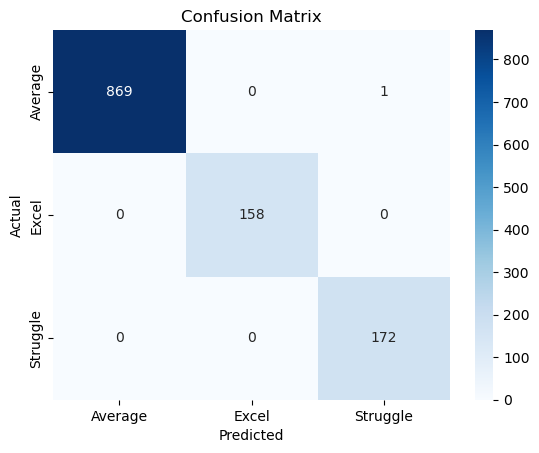

In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [7]:
# --- Improved Sorted Feature Importance Visualization ---
importances = rf.feature_importances_
features = X.columns

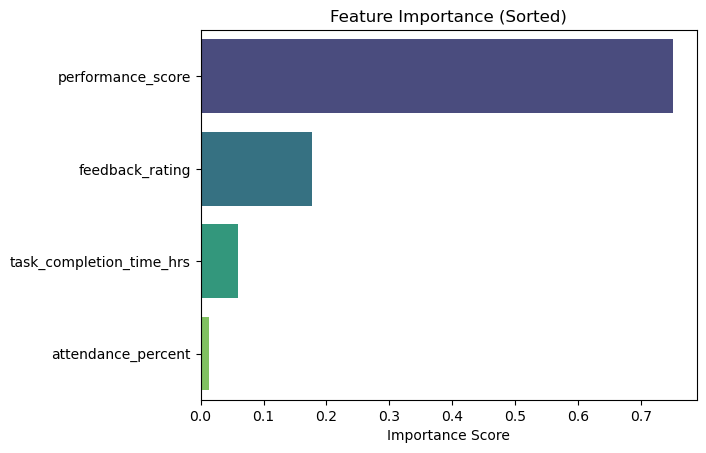

In [16]:
# Sort features by importance values
indices = np.argsort(importances)[::-1]
sorted_features = [features[i] for i in indices]
sorted_importances = importances[indices]
sns.barplot(x=sorted_importances, y=sorted_features, hue=sorted_features, palette="viridis", legend=False)
plt.title("Feature Importance (Sorted)")
plt.xlabel("Importance Score")
plt.show()


In [9]:
# Cross-validation for robustness
cv_scores = cross_val_score(rf, X, y, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Cross-validation scores: [0.99916667 1.         0.99916667 0.99916667 0.9975    ]
Mean CV Accuracy: 0.9989999999999999


In [18]:
# === Improved Real-Time User Input Prediction with Basic Boundary Validation ===

def predict_intern_performance():
    print("\n--- Enter intern details below ---")

    task_time = float(input("Task completion time (hrs): "))
    
    # Validation loop for feedback scale
    while True:
        feedback = float(input("Feedback rating (1.0 to 5.0): "))
        if 1.0 <= feedback <= 5.0:
            break
        print("Out of range! Please enter a rating between 1.0 and 5.0.")

    # Validation loop for attendance percentage
    while True:
        attendance = float(input("Attendance percent (0 to 100): "))
        if 0 <= attendance <= 100:
            break
        print("Invalid percentage! Please enter a value between 0 and 100.")

    score = float(input("Performance score: "))

    # Create dataframe for prediction
    new_data = pd.DataFrame({
        'task_completion_time_hrs': [task_time],
        'feedback_rating': [feedback],
        'attendance_percent': [attendance],
        'performance_score': [score]
    })

    # Predict category and confidence probabilities
    prediction = rf.predict(new_data)[0]
    probabilities = rf.predict_proba(new_data)[0]

    print("\nPredicted Performance Category:", prediction)
    print("\nConfidence Scores:")
    for cls, prob in zip(rf.classes_, probabilities):
        print(f"  🔹 {cls}: {prob * 100:.1f}%")
        
# Run the function
predict_intern_performance()


--- Enter intern details below ---


Task completion time (hrs):  7
Feedback rating (1.0 to 5.0):  3
Attendance percent (0 to 100):  70
Performance score:  60



Predicted Performance Category: Average

Confidence Scores:
  🔹 Average: 98.0%
  🔹 Excel: 0.0%
  🔹 Struggle: 2.0%
